# Projet de prediction des earthquake-tsunami

## A porpos des donnees


**Feature Description**
|Feature |	Type |	Description	| Range/Values	| Tsunami Relevance |
|-------|--------|--------------|--------------|--------------------|
|magnitude	| Float |	Earthquake magnitude (Richter scale) |	6.5 - 9.1	| High - Primary tsunami predictor|
|cdi |	Integer|	Community Decimal Intensity (felt intensity)	| 0 - 9	| Medium - Population impact measure |
|mmi |	Integer |	Modified Mercalli Intensity (instrumental) |	1 - 9	| Medium - Structural damage indicator |
|sig |	Integer	Event significance score |	650 - 2910 | High - Overall hazard assessment|
|nst	|Integer|	Number of seismic monitoring stations	|0 - 934|	Low - Data quality indicator|
|dmin	|Float	|Distance to nearest seismic station (degrees)|	0.0 - 17.7|	Low - Location precision|
|gap|	Float	|Azimuthal gap between stations (degrees)	|0.0 - 239.0|	Low - Location reliability|
|depth|	Float	|Earthquake focal depth (km)	|2.7 - 670.8	|High - Shallow = higher tsunami risk|
|latitude	|Float	|Epicenter latitude (WGS84)	|-61.85° to 71.63°	|High - Ocean proximity indicator|
|longitude	|Float	|Epicenter longitude (WGS84)	|-179.97° to 179.66°|	High - Ocean proximity indicator|
|Year	|Integer	|Year of occurrence|	2001 - 2022|	Medium - Temporal patterns|
|Month|	Integer	|Month of occurrence|	1 - 12	|Low - Seasonal analysis|
|tsunami|	Binary	|Tsunami potential (TARGET)	|0, 1	|TARGET VARIABLE|

## Importer les librairies necessaires

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import joblib

import warnings
warnings.filterwarnings("ignore")

## Importer les donnees 

In [39]:
data = pd.read_csv('../data/raw/earthquake_data_tsunami.csv')

## Analyse des donnees

In [40]:
data.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [42]:
data.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [43]:
data.isna().sum()
data.describe(include='all')


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


## EDA

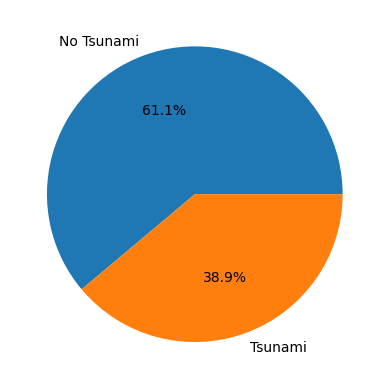

In [44]:
plt.pie(data['tsunami'].value_counts(), labels=['No Tsunami', 'Tsunami'], autopct='%1.1f%%')
plt.show()

### Distribution univariee

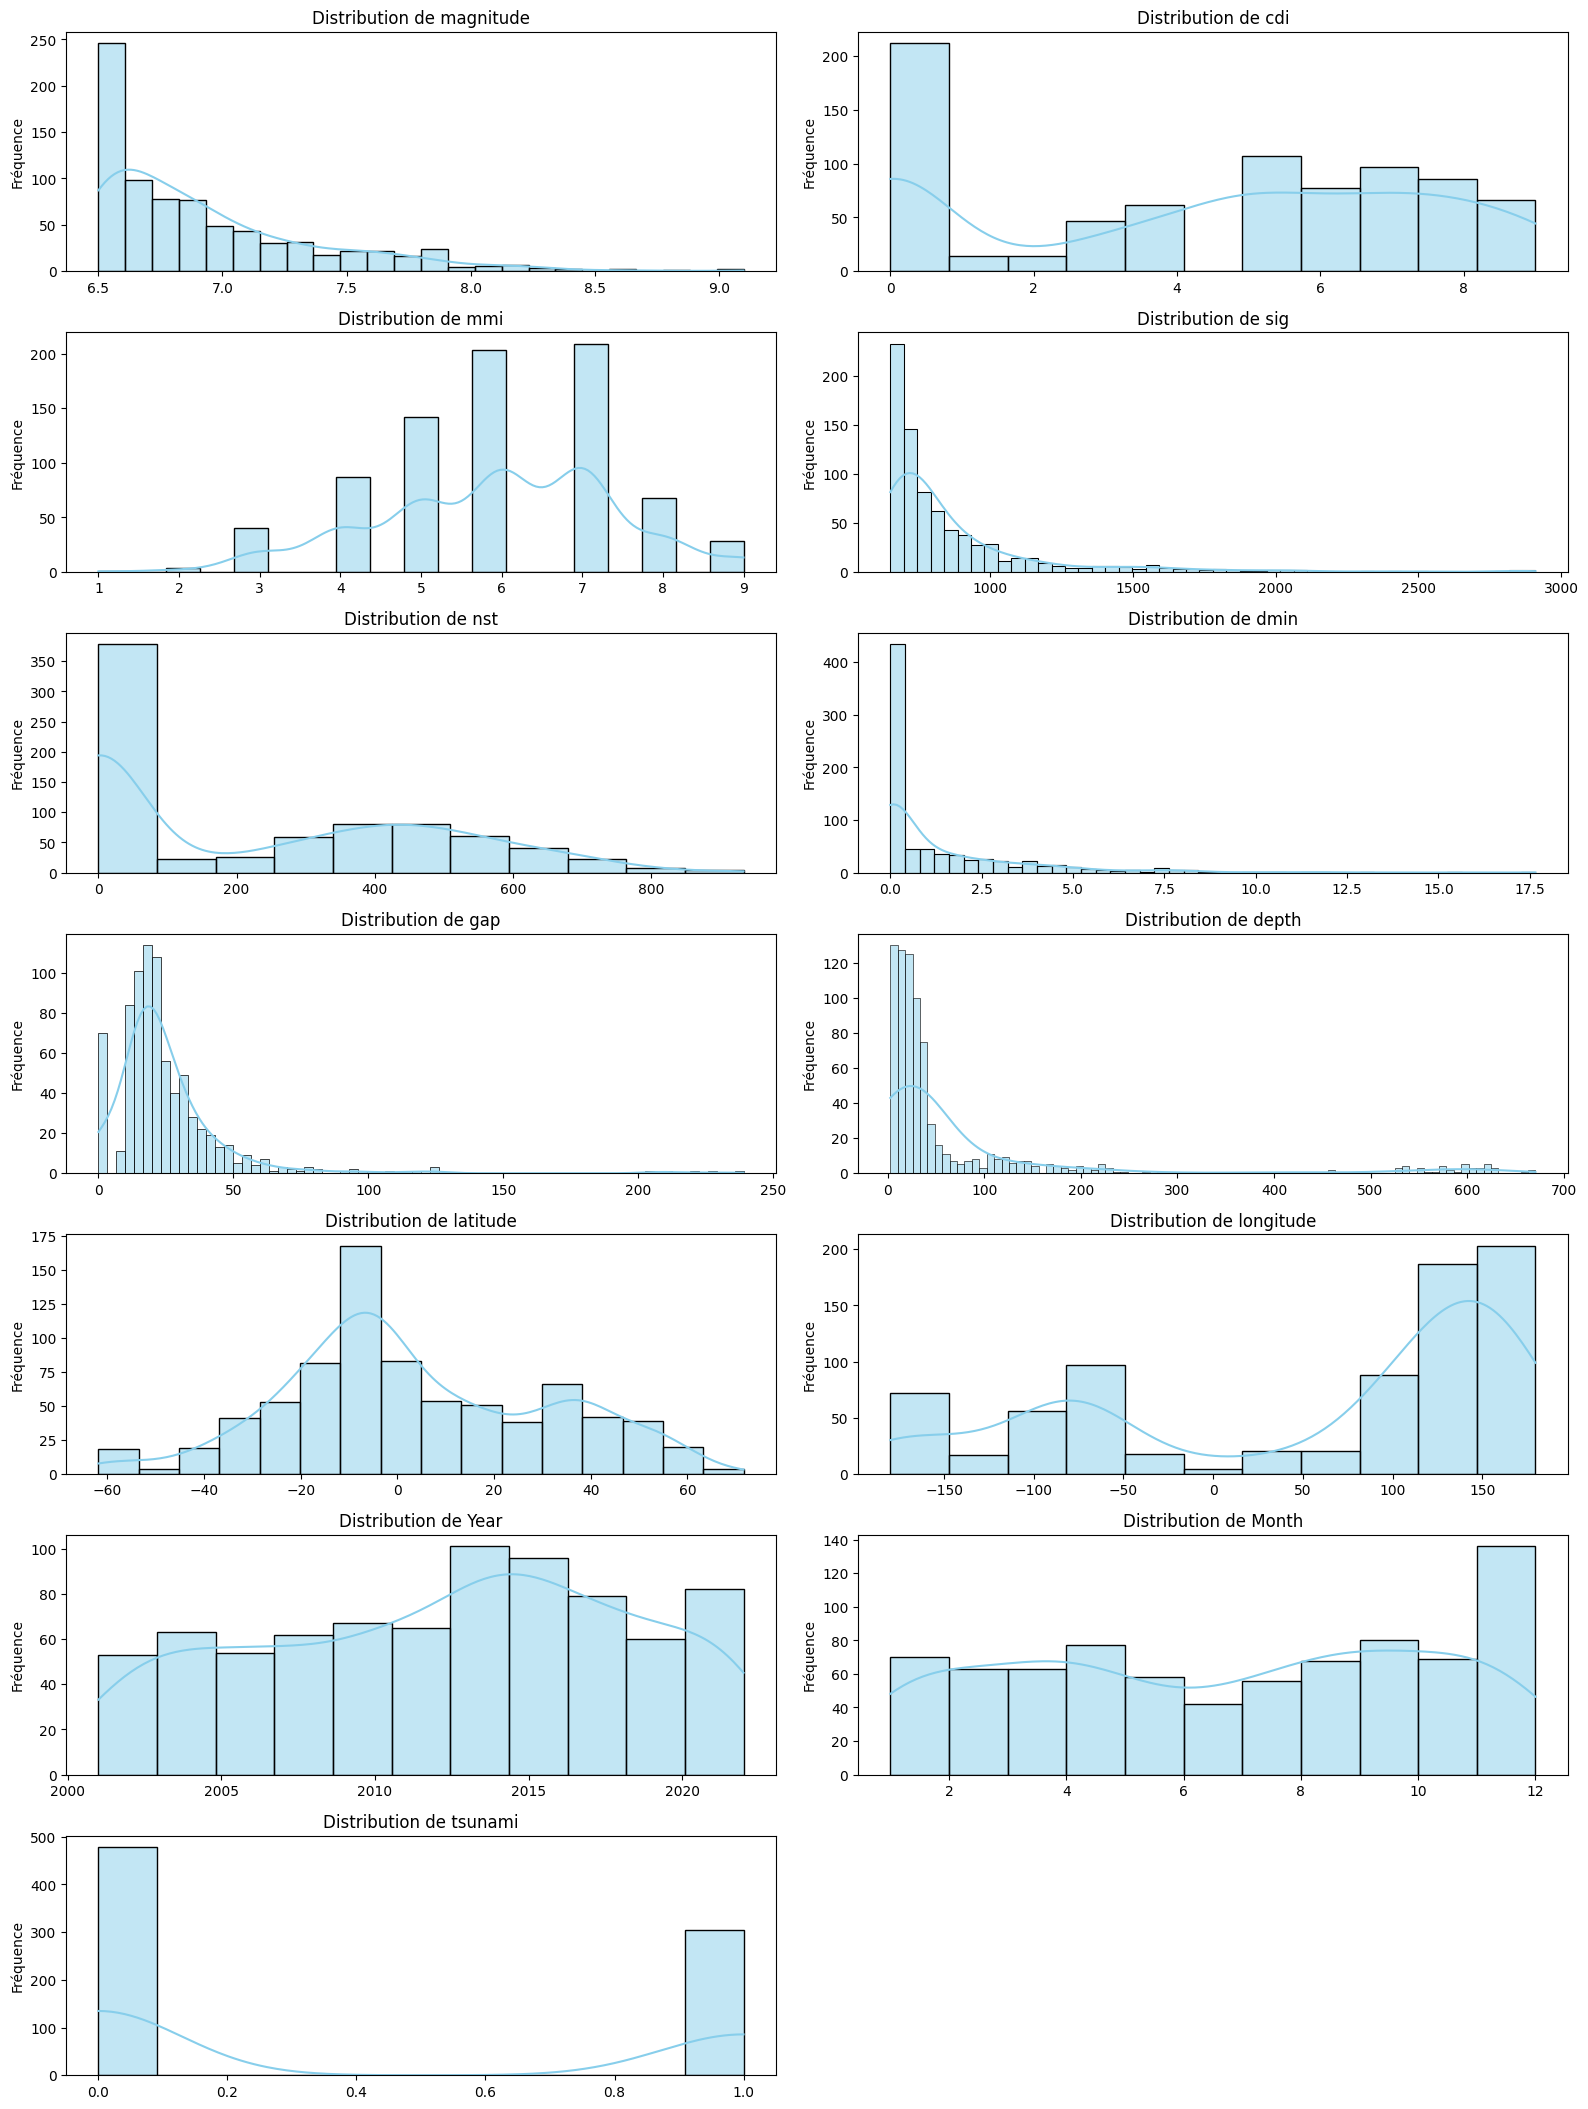

In [45]:
# Sélectionner les colonnes numériques
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Définir la taille générale de la figure
plt.figure(figsize=(16, len(num_cols)*3))

# Afficher un histogramme pour chaque variable
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, i)
    sns.histplot(data[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel('')
    plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

In [46]:
# Sélectionner les colonnes catégoriques
cat_cols = data.select_dtypes(include=['object', 'category']).columns

plt.figure(figsize=(16, len(cat_cols)*3))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    data[col].value_counts().head(10).plot(kind='bar', color='orange')
    plt.title(f'Distribution des catégories de {col}')
    plt.xlabel('')
    plt.ylabel('Nombre d’occurrences')

plt.tight_layout()
plt.show()


<Figure size 1600x0 with 0 Axes>

### Distribution bivariee

A. Numérique ↔ Numérique : Scatterplot ou Heatmap

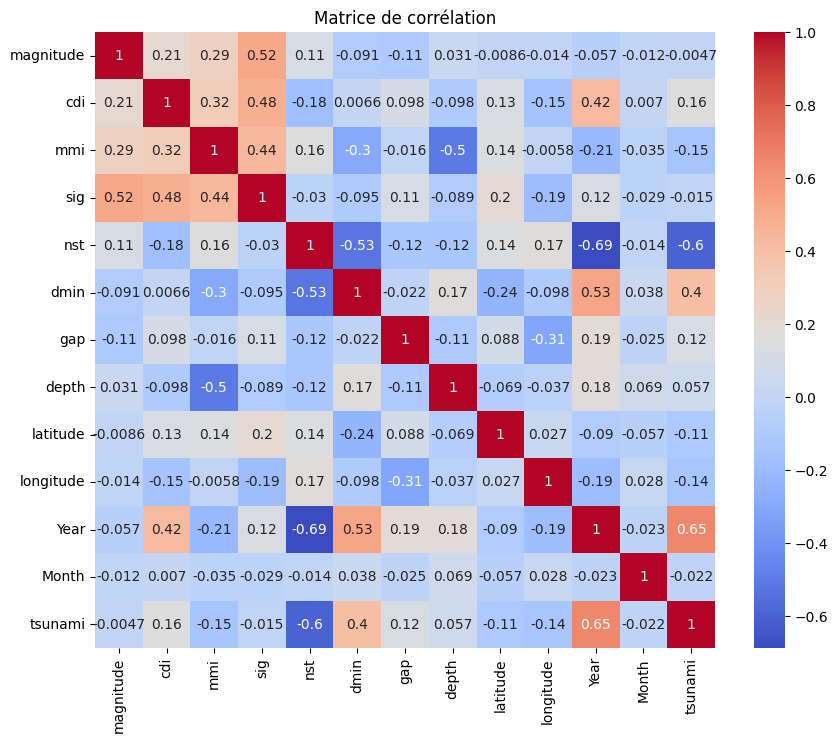

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

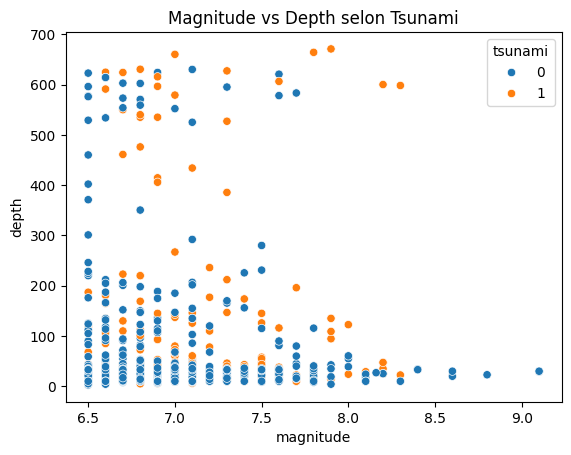

In [48]:
sns.scatterplot(x='magnitude', y='depth', hue='tsunami', data=data)
plt.title("Magnitude vs Depth selon Tsunami")
plt.show()


B. Catégorique ↔ Numérique : Boxplot ou Violin plot

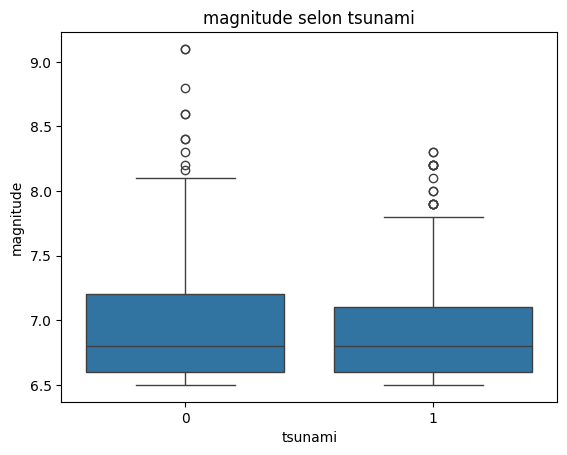

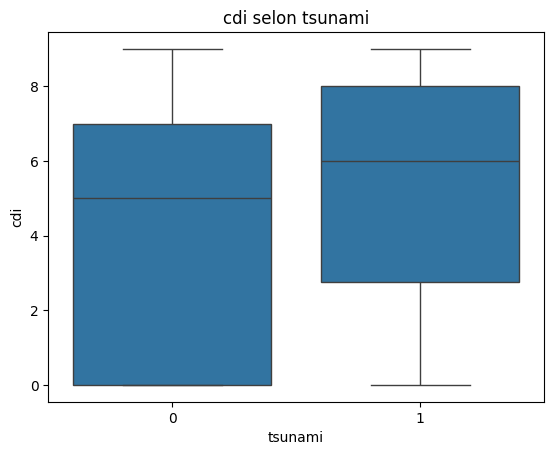

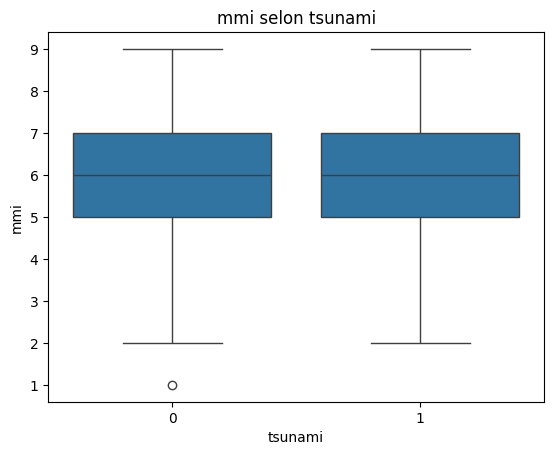

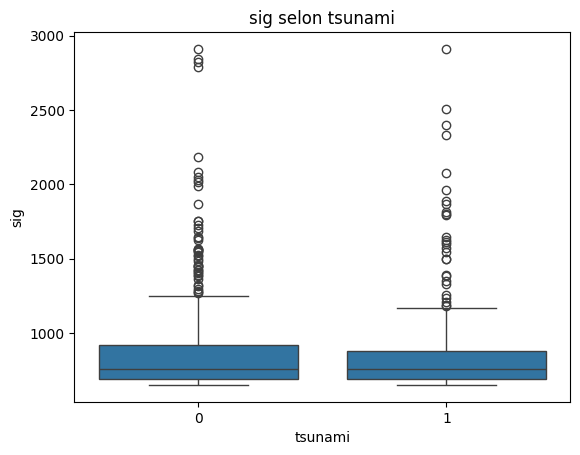

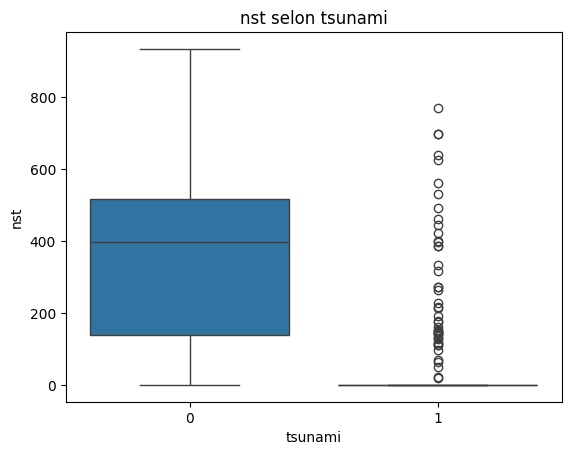

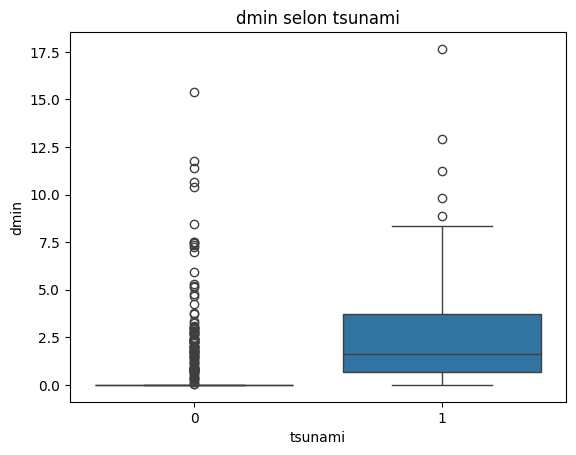

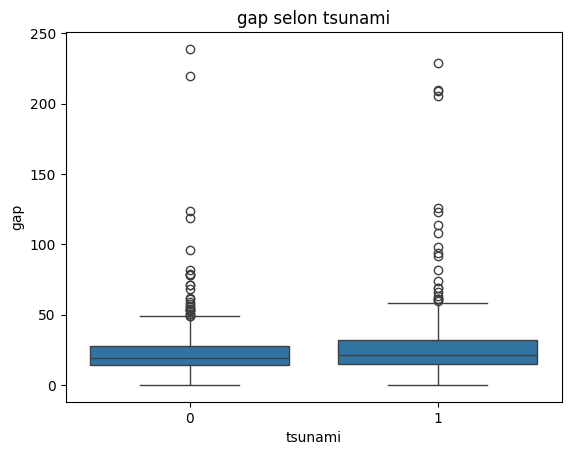

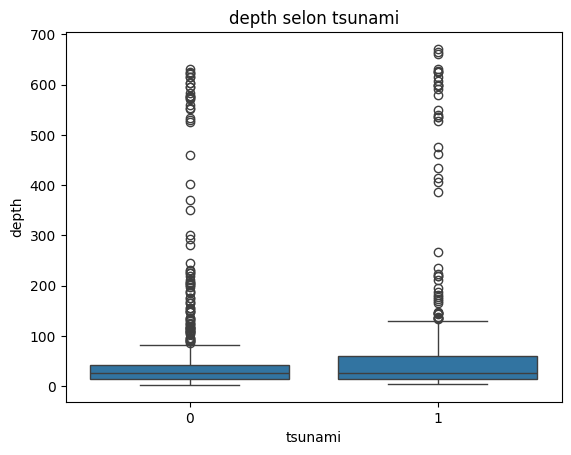

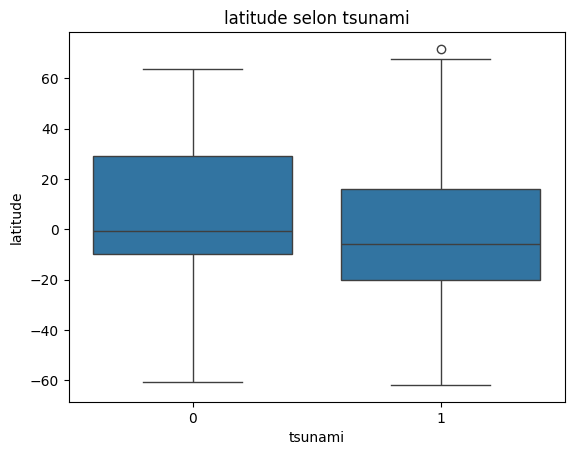

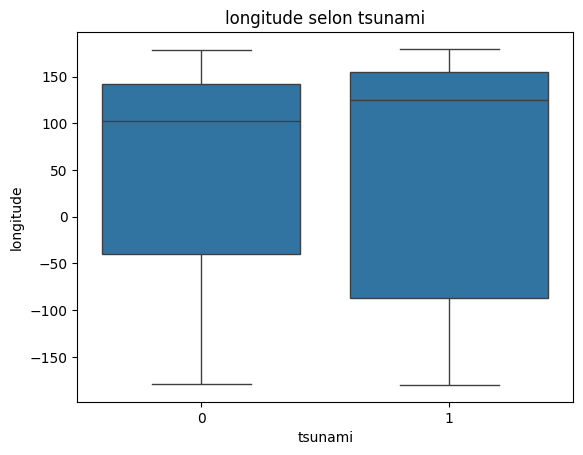

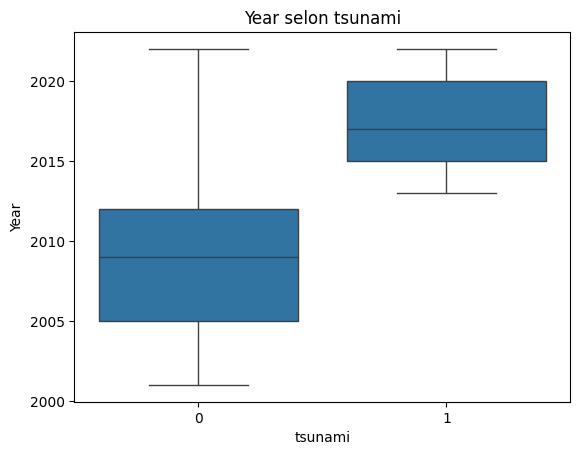

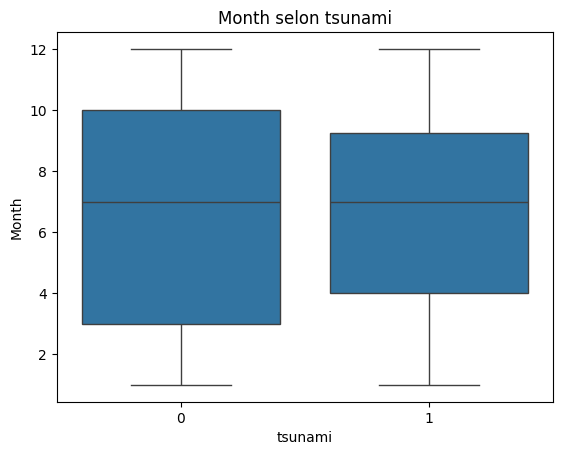

In [49]:
target = 'tsunami'

# Si la cible est binaire/catégorielle
if data[target].nunique() <= 10:
    # Comparer chaque numérique avec la cible
    num_cols = data.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if col != target:
            sns.boxplot(x=target, y=col, data=data)
            plt.title(f'{col} selon {target}')
            plt.show()
else:
    # Si la cible est numérique
    num_cols = data.select_dtypes(include=['int64', 'float64']).columns
    corr = data[num_cols].corr()[target].sort_values(ascending=False)
    print("Corrélations avec la cible :\n", corr)


## Preprocessing data

In [50]:
def preprocess_data(data: pd.DataFrame, target_col='tsunami'):
    """
    Prétraitement des données :
    - suppression des doublons et valeurs manquantes
    - encodage des variables catégorielles
    - normalisation des variables numériques (sauf la cible)
    - retour du DataFrame nettoyé
    """

    data = data.copy()

    # 1️⃣ Supprimer les doublons
    data = data.drop_duplicates()

    # 2️⃣ Supprimer les colonnes avec trop de valeurs manquantes
    seuil_nan = 0.5  # 50% de valeurs manquantes max
    data = data.loc[:, data.isnull().mean() < seuil_nan]

    # 3️⃣ Remplir les valeurs manquantes restantes
    for col in data.columns:
        if data[col].dtype == 'object':
            data[col] = data[col].fillna(data[col].mode()[0])  # valeur la plus fréquente
        else:
            data[col] = data[col].fillna(data[col].median())  # médiane

    # 4️⃣ Encodage des variables catégorielles
    label_encoders = {}
    for col in data.select_dtypes(include='object').columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

    # Assurer que la cible est entière
    if target_col in data.columns:
        data[target_col] = data[target_col].astype(int)

    # 5️⃣ Normalisation des variables numériques (sauf la cible)
    scaler = StandardScaler()
    numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    if numeric_cols:
        data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

    return data

In [51]:
data_preprocessed = preprocess_data(data)

### Split les donnees

In [52]:
# Utiliser les données prétraitées
X = data_preprocessed.drop(columns=['tsunami'])
y = data_preprocessed['tsunami']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train modele

In [53]:
# Définir et entraîner le modèle
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Sauvegarder le modèle entraîné
joblib.dump(model, '../models/rf_tsunami_model.joblib')

['../models/rf_tsunami_model.joblib']

## Predict

Accuracy: 0.9426751592356688

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        96
           1       0.89      0.97      0.93        61

    accuracy                           0.94       157
   macro avg       0.94      0.95      0.94       157
weighted avg       0.95      0.94      0.94       157


Confusion matrix:
 [[89  7]
 [ 2 59]]

ROC AUC: 0.9690915300546449


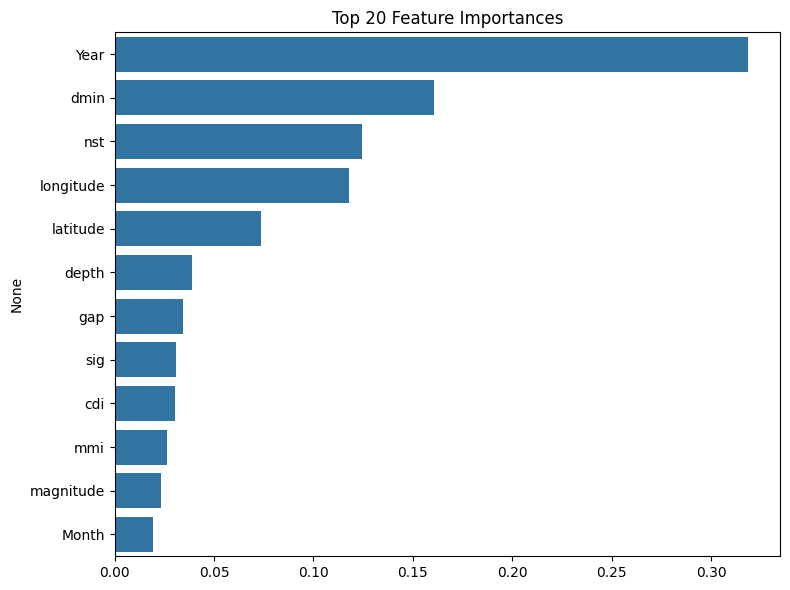

In [ ]:
# Évaluation sur le jeu de test
y_pred = model.predict(X_test)

# Probabilités si disponibles
y_proba = None
if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
if y_proba is not None:
    try:
        print("\nROC AUC:", roc_auc_score(y_test, y_proba))
    except Exception:
        pass

# Feature importances
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()